---
title: C.3re tanglegrams 
author: Elgin Akin
date: 2025-05-19
---

Useful resources: 
- [baltic](https://github.com/evogytis/baltic/blob/master/docs/notebooks/austechia.ipynb)
- [A nice blog by Gytis on reassortment](https://evogytis.github.io/posts/2020/10/reassortment/)

# Global Notebook Parameters


In [1]:
# Subclade Colors

subclade_colors = {
            "C.5.1": "#e7298a",
            "C.5.5": "#66c2a5",
            "C.5.6": "#a6761d",
            "C.5.7": "#666666",
            "C.5": "#e6ab02",
            "C.3": "#2E6F40",
            "C.2": "#7570b3",
            "C": "#d95f02"
        }

subclade_colors = {
            "C.5.1": "#FF5003",
            "C.5.5": "#66c2a5", # remove - minor C.5 lineage
            "C.5.6": "#a6761d",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            #"C.2": "grey", # remove C.2 
            "C": "#A50104" # vaccine
        }

# restrict gene-tree colored clades to be major C.5.X lineages and C.3.X lineages. 

subclade_colors = {
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C.5": "#e6ab02",
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C": "#A50104" # vaccine
        }
        

# Plot HA colored by subclade

In [2]:
import os
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Set global fonts once 
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 200
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(5, 8),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14,
    save_path=None,
    add_legend=False,
    legend_loc="lower left"
):
    # Default subclade color palette if none provided
    if subclade_colors is None:
        subclade_colors = {
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C.5": "#e6ab02",
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C": "#A50104" # vaccine
        }

    # Load tree
    tree = bt.loadJSON(tree_file)

    # Define color function for tips by subclade
    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    # Prepare figure and axis
    fig, ax = plt.subplots(figsize=figsize, facecolor='w')
    x_attr = lambda k: k.absoluteTime

    # Plot tree
    tree[0].plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    tree[0].plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # X-axis year range and background bars
    all_dates = [k.absoluteTime for k in tree[0].Objects]
    min_year = int(min(all_dates))
    max_year = int(max(all_dates)) + 1
    for i, year in enumerate(range(min_year, max_year)):
        ax.axvspan(year, year + 1, facecolor='grey' if i % 2 == 0 else 'white', alpha=0.1 if i % 2 == 0 else 0, edgecolor='none')

    ax.set_xticks(range(min_year, max_year))
    ax.set_xticklabels([str(y) for y in range(min_year, max_year)])

    # Highlight vaccine strain
    for k in tree[0].Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            ax.scatter(
                k.absoluteTime, k.y,
                s=150, marker='X',
                facecolors=subclade_colors["C"],
                edgecolors='black',
                linewidths=1.5,
                zorder=200
            )
            break

    # Optional labels
    if add_labels:
        max_x = max(k.absoluteTime for k in tree[0].Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree[0].Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=10, color='black')

    # Format axes
    ax.xaxis.tick_bottom()
    ax.tick_params(axis='x', labelsize=x_labelsize)
    ax.set_ylim(-5, tree[0].ySpan + 5)
    ax.set_yticks([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc != 'bottom']

    # Optional legend
    if add_legend:
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', label=subclade,
                   markerfacecolor=color, markeredgecolor='black', markersize=10)
            for subclade, color in subclade_colors.items()
        ]
        legend_elements.append(
            Line2D([0], [0], marker='X', color='w', label='Vaccine',
                   markerfacecolor=subclade_colors["C"], markeredgecolor='black', markersize=12)
        )
        ax.legend(handles=legend_elements, loc=legend_loc, title="Subclades", fontsize=12, title_fontsize=14)

    # Save or show
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
    else:
        plt.show()


In [3]:

plot_influenza_tree("../auspice/vic/genome.json", x_labelsize=8.5, save_path="../figures/phylogeny_genome.png", add_legend=True, legend_loc="lower left")

plot_influenza_tree("../auspice/vic/ha.json", x_labelsize=8.5, save_path="../figures/phylogeny_ha.png")

plot_influenza_tree("../auspice/vic/na.json", x_labelsize=8.5, save_path="../figures/phylogeny_na.png")

plot_influenza_tree("../auspice/vic/pa.json", x_labelsize=8.5, save_path="../figures/phylogeny_pa.png")

plot_influenza_tree("../auspice/vic/ns.json", x_labelsize=10.5, save_path="../figures/phylogeny_ns.png")


Tree height: 9.534000
Tree length: 1550.746000

Numbers of objects in tree: 6144 (3004 nodes and 3140 leaves)


Tree height: 8.975000
Tree length: 1208.465000

Numbers of objects in tree: 5464 (2324 nodes and 3140 leaves)


Tree height: 11.363000
Tree length: 1400.811000

Numbers of objects in tree: 5376 (2236 nodes and 3140 leaves)


Tree height: 8.270000
Tree length: 1162.029000

Numbers of objects in tree: 5723 (2583 nodes and 3140 leaves)


Tree height: 10.452000
Tree length: 1759.018000

Numbers of objects in tree: 5374 (2234 nodes and 3140 leaves)



## Grid-like Function


Tree height: 9.534000
Tree length: 1550.746000

Numbers of objects in tree: 6144 (3004 nodes and 3140 leaves)


Tree height: 10.413000
Tree length: 1472.333000

Numbers of objects in tree: 5662 (2522 nodes and 3140 leaves)


Tree height: 7.100000
Tree length: 1430.181000

Numbers of objects in tree: 5609 (2469 nodes and 3140 leaves)


Tree height: 8.270000
Tree length: 1162.029000

Numbers of objects in tree: 5723 (2583 nodes and 3140 leaves)


Tree height: 8.975000
Tree length: 1208.465000

Numbers of objects in tree: 5464 (2324 nodes and 3140 leaves)


Tree height: 7.475000
Tree length: 1335.559000

Numbers of objects in tree: 5621 (2481 nodes and 3140 leaves)


Tree height: 11.363000
Tree length: 1400.811000

Numbers of objects in tree: 5376 (2236 nodes and 3140 leaves)


Tree height: 10.581000
Tree length: 1697.629000

Numbers of objects in tree: 5448 (2308 nodes and 3140 leaves)


Tree height: 10.452000
Tree length: 1759.018000

Numbers of objects in tree: 5374 (2234 nodes and 31

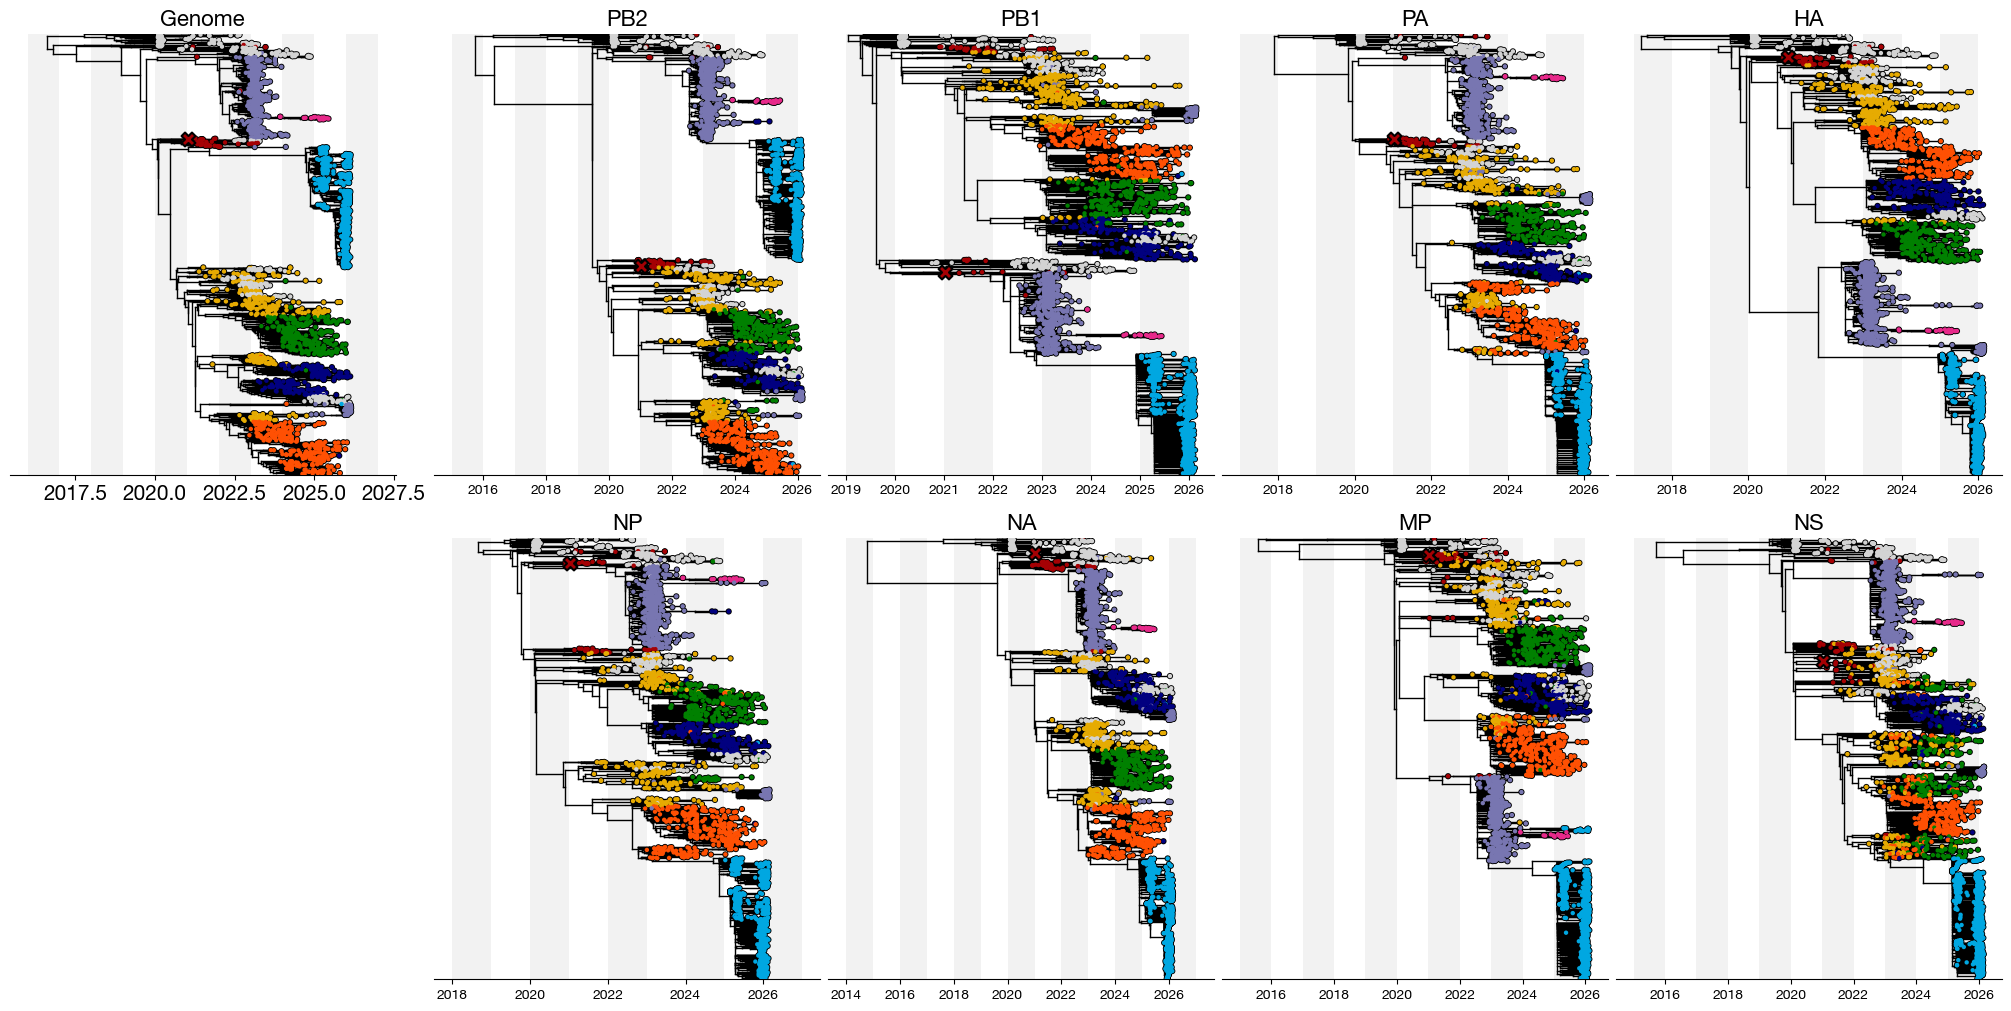

In [4]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from datetime import datetime

# Global font settings
typeface = 'Helvetica Neue'
mpl.rcParams['font.weight'] = 300
mpl.rcParams['axes.labelweight'] = 300
mpl.rcParams['font.family'] = typeface
mpl.rcParams['font.size'] = 22

def plot_influenza_tree(
    tree_file,
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)",
    subclade_colors=None,
    figsize=(3, 12),
    add_labels=False,
    label_distance=0.8,
    x_labelsize=14,
    ax=None,
    title=None
):
    if subclade_colors is None:
        subclade_colors = {
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.3.2": "#e7298a",
            "C.5": "#e6ab02",
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green",
            "C": "#A50104" # vaccine
        }

    tree = bt.loadJSON(tree_file)

    def c_func(node):
        subclade = node.traits.get('subclade')
        return subclade_colors.get(subclade, 'lightgrey')

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, facecolor='w')

    x_attr = lambda k: k.absoluteTime
    tree[0].plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    tree[0].plotPoints(ax, x_attr=x_attr, size=10, outline=True, outline_colour="black", colour=c_func, zorder=100)

    # Calculate date bounds from all nodes
    node_dates = [k.absoluteTime for k in tree[0].Objects if hasattr(k, 'absoluteTime')]
    min_year = int(min(node_dates))
    max_year = int(max(node_dates)) + 1

    for i, year in enumerate(range(min_year, max_year)):
        if i % 2 == 0:
            ax.axvspan(year, year + 1, facecolor='grey', alpha=0.1, edgecolor='none', zorder=0)

    # Mark vaccine strain
    for k in tree[0].Objects:
        if k.is_leaf() and k.name == vaccine_strain:
            ax.scatter(
                k.absoluteTime, k.y, s=100, marker='X',
                facecolor=subclade_colors["C"], edgecolor='black',
                linewidth=1.5, zorder=200
            )
            break

    if add_labels:
        max_x = max(k.absoluteTime for k in tree[0].Objects if k.is_leaf())
        label_x = max_x + label_distance
        for k in tree[0].Objects:
            if k.is_leaf():
                ax.plot([k.absoluteTime, label_x], [k.y, k.y], color='gray', linestyle=':', linewidth=1)
                ax.text(label_x + 0.1, k.y, k.name, va='center', ha='left', size=15, color='black')

    ax.xaxis.tick_bottom()
    ax.set_ylim(-5, tree[0].ySpan + 5)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.tick_params(axis='x', labelsize=x_labelsize)
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    if title:
        ax.set_title(title, fontsize=16)

def plot_segment_grid_with_genome(segment_paths, segment_names, genome_path, figsize=(20, 10)):
    fig, axs = plt.subplots(2, 5, figsize=figsize, facecolor='w', constrained_layout=True)
    axs = axs.flatten()

    # Plot genome tree in top-left (index 0)
    plot_influenza_tree(
        tree_file=genome_path,
        ax=axs[0],
        title="Genome",
        x_labelsize=15
    )

    # Skip axs[5] (bottom-left, 1st col 2nd row) — index 5
    skip_index = 5
    seg_idx = 0
    for i in range(1, len(axs)):
        if i == skip_index:
            axs[i].axis('off')  # Leave blank
            continue
        if seg_idx < len(segment_paths):
            plot_influenza_tree(
                tree_file=segment_paths[seg_idx],
                ax=axs[i],
                title=segment_names[seg_idx],
                x_labelsize=10
            )
            seg_idx += 1

    plt.show()

# === Usage ===
segment_paths = [
    "../auspice/vic/pb2.json",
    "../auspice/vic/pb1.json",
    "../auspice/vic/pa.json",
    "../auspice/vic/ha.json",
    "../auspice/vic/np.json",
    "../auspice/vic/na.json",
    "../auspice/vic/mp.json",
    "../auspice/vic/ns.json"
]
segment_names = ["PB2", "PB1", "PA", "HA", "NP", "NA", "MP", "NS"]
genome_path = "../auspice/vic/genome.json"

plot_segment_grid_with_genome(segment_paths, segment_names, genome_path)


## Tanglegram


> Copy over all auspice json's to a new sub-directory for easly looping and plotting


Sources: 
- https://github.com/dven42/phylogenetic-incongruence/blob/master/BALTIC.ipynb
- https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1006466
- https://github.com/blab/siv-cst/blob/master/figures/main-text/F1-recombination.ipynb

## Import Trees for All Tanglegram Functions

In [8]:
import baltic as bt
from glob import glob
from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo


treefiles = glob('../auspice/plotting/*.json')


segments=['PB1','PB2','PA','HA','NP','NA','MP','NS']

trees={} ## dict
for segment in segments:
    print(segment, )
    tree_location = f"../auspice/vic/{segment}.json"

    ll = bt.loadJSON(tree_location)
    trees[segment]=ll[0] ## add ONLY the tree object to dict

print('\nDone!')

PB1

Tree height: 7.100000
Tree length: 1430.181000

Numbers of objects in tree: 5609 (2469 nodes and 3140 leaves)

PB2

Tree height: 10.413000
Tree length: 1472.333000

Numbers of objects in tree: 5662 (2522 nodes and 3140 leaves)

PA

Tree height: 8.270000
Tree length: 1162.029000

Numbers of objects in tree: 5723 (2583 nodes and 3140 leaves)

HA

Tree height: 8.975000
Tree length: 1208.465000

Numbers of objects in tree: 5464 (2324 nodes and 3140 leaves)

NP

Tree height: 7.475000
Tree length: 1335.559000

Numbers of objects in tree: 5621 (2481 nodes and 3140 leaves)

NA

Tree height: 11.363000
Tree length: 1400.811000

Numbers of objects in tree: 5376 (2236 nodes and 3140 leaves)

MP

Tree height: 10.581000
Tree length: 1697.629000

Numbers of objects in tree: 5448 (2308 nodes and 3140 leaves)

NS

Tree height: 10.452000
Tree length: 1759.018000

Numbers of objects in tree: 5374 (2234 nodes and 3140 leaves)


Done!


#### Function for Plotting a 2-tree Tanglegram

In [ ]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

def plot_two_segment_tanglegram(
    tree1_name,
    tree2_name,
    subclade_colors,
    trees,
    traitName='subclade',
    tip_shapes=None,
    figsize=(20, 20),
    save_path=None
):
    fig = plt.figure(figsize=figsize, facecolor='w')
    gs = GridSpec(1, 1, hspace=0.0, wspace=0.0)
    ax = plt.subplot(gs[0])

    tree1 = trees[tree1_name]
    tree2 = trees[tree2_name]

    def c_func(k):
        return subclade_colors.get(k.traits.get(traitName), 'grey')

    x_attr1 = lambda k: k.height
    tree1.plotTree(ax, x_attr=x_attr1, width=1, colour=c_func)
    tree1.plotPoints(ax, x_attr=x_attr1, size=10, colour=c_func, zorder=100)

    max_yspan = max(tree1.ySpan, tree2.ySpan)
    ax.text(
        tree1.treeHeight / 2,
        max_yspan + 2.5,
        tree1_name,
        ha='center',
        va='bottom',
        fontsize=40,
        fontweight='normal'
    )

    skip = tree1.treeHeight * 0.35
    x_attr2 = lambda k: tree1.treeHeight + skip + tree2.treeHeight - k.height
    tree2.plotTree(ax, x_attr=x_attr2, width=1, colour=c_func)
    tree2.plotPoints(ax, x_attr=x_attr2, size=10, colour=c_func, zorder=100)

    ax.text(
        tree1.treeHeight + skip + tree2.treeHeight / 2,
        max_yspan + 2.5,
        tree2_name,
        ha='center',
        va='bottom',
        fontsize=40,
        fontweight='normal'
    )

    # ---- Specific Strain Annotation ----
    if tip_shapes:
        for tree, x_attr in zip([tree1, tree2], [x_attr1, x_attr2]):
            for k in tree.Objects:
                if k.branchType == 'leaf' and k.name in tip_shapes:
                    shape = tip_shapes[k.name]
                    ax.plot(
                        x_attr(k), k.y,
                        marker=shape.get("marker", "o"),
                        markerfacecolor=shape.get("facecolor", "white"),
                        markeredgecolor=shape.get("edgecolor", "black"),
                        markeredgewidth=shape.get("markeredgewidth", 1.5),
                        markersize=shape.get("markersize", 20),
                        linestyle='None',
                        zorder=shape.get("zorder", 200)
                    )

    # ---- Tangle lines with zorder ----
    for zorder_level in [0, 1, 2]:
        for k in filter(lambda x: x.branchType == 'leaf', tree1.Objects):
            x = k.height
            y = k.y
            subclade = k.traits.get(traitName)
            color = subclade_colors.get(subclade, 'grey')
            if subclade == 'C.3':
                z = 2
            elif subclade in subclade_colors:
                z = 1
            else:
                z = 0
            if z != zorder_level:
                continue

            matching = tree2.getBranches(
                lambda x2: x2.branchType == 'leaf' and x2.name == k.name,
                warn=False
            )
            if not matching:
                continue
            matching_tip = matching[0] if isinstance(matching, list) else matching
            match_y = matching_tip.y
            xs = [x, tree1.treeHeight + 0.15 * skip,
                  tree1.treeHeight + skip - 0.15 * skip,
                  x_attr2(matching_tip)]
            ys = [y, y, match_y, match_y]

            ax.plot(xs, ys, color=color, alpha=0.7, zorder=z)

    # ---- Clean up plot ----
    for loc in ['top', 'right', 'left', 'bottom']:
        ax.spines[loc].set_visible(False)
    ax.tick_params(axis='x', size=0)
    ax.tick_params(axis='y', size=0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    y_buffer = max_yspan * 0.05
    ax.set_ylim(-y_buffer, max_yspan + y_buffer + 3)
    ax.set_xlim(-5, tree1.treeHeight + skip + tree2.treeHeight + 5)

    plt.tight_layout()

    # ---- Legends ----
    # Subclades actually present
    present_subclades = {
        k.traits.get(traitName)
        for tree in [tree1, tree2]
        for k in tree.Objects
        if k.branchType == 'leaf'
    }

    # Subclade color legend
    legend_clades = [
        Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=color,
            markeredgecolor='black',
            markeredgewidth=1,
            markersize=15,
            linestyle='None',
            label=subclade
        )
        for subclade, color in subclade_colors.items()
        if subclade in present_subclades
    ]
    
    # Add "Other Subclades" if there are any not in subclade_colors

    if any(s not in subclade_colors for s in present_subclades if s is not None):
        legend_clades.append(
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor='lightgrey',
                markeredgecolor='black',
                markeredgewidth=1,
                markersize=15,
                linestyle='None',
                label='Other Subclades'
            )
        )

    legend_shapes = []
    if tip_shapes:
        legend_shapes = [
            Line2D(
                [0], [0],
                marker=shape.get("marker", "o"),
                label=shape.get("display_name", tip),  # Use display_name if provided, otherwise use tip
                markerfacecolor=shape.get("facecolor", "white"),
                markeredgecolor=shape.get("edgecolor", "black"),
                markeredgewidth=1.5,
                markersize=shape.get("markersize", 12),  # Reduced size for legend
                linestyle='None',
                color='w'
            )
            for tip, shape in tip_shapes.items()
        ]

    # HA Subclade legend - bottom right, smaller
    legend1 = ax.legend(
        handles=legend_clades,
        loc='lower right',
        bbox_to_anchor=(1.0, 0.15),  # Positioned above the strain legend
        fontsize=8,
        frameon=True,
        title="HA Subclade",
        title_fontsize=10
    )
    ax.add_artist(legend1)

    # Strain legend - bottom right, below HA subclade legend
    if legend_shapes:
        legend2 = ax.legend(
            handles=legend_shapes,
            loc='lower right',
            bbox_to_anchor=(1.0, 0.0),  # At the bottom right
            fontsize=8,
            frameon=True,
            title="Representative Strain",
            title_fontsize=10
        )
        ax.add_artist(legend2)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved tanglegram to {save_path}")
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# Plot 2 Segment Tanglegrams 

Minor C.3 reassortment events with C.5.X lineages are ambiguous due to low circulating frequency of these events. HA clade nomenclature from Strains belonging to the C.3/re.1 may soon be updated to C.3.3. Since our clade assignment was called with Nextclade on XXXX-XX-XX, this will not be reflected here. 


Saved tanglegram to ../figures/phylogeny_tanglegram_HA_NA.png


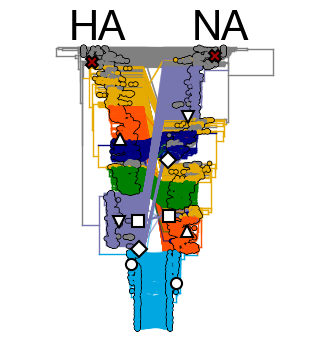

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_PB2.png


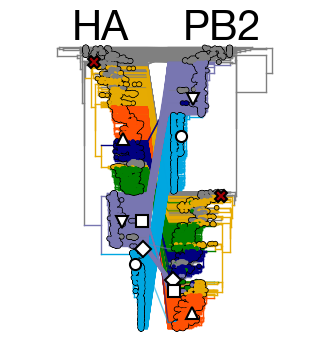

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_PB1.png


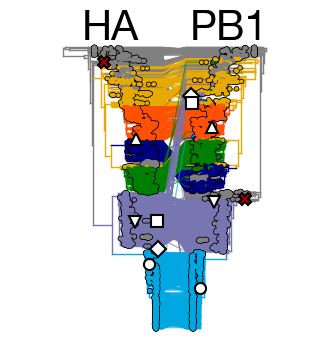

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_PA.png


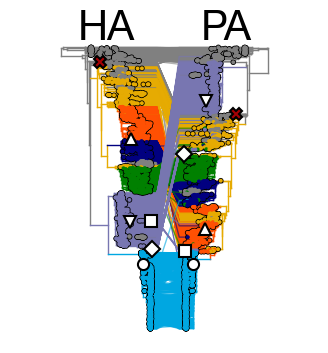

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_NP.png


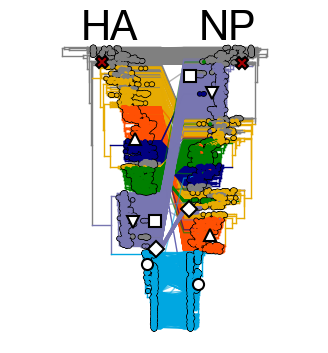

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_MP.png


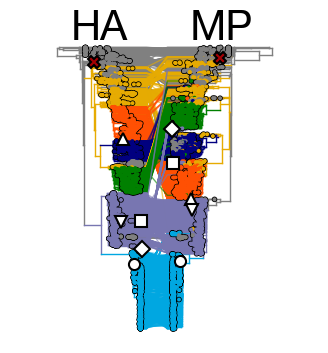

Saved tanglegram to ../figures/phylogeny_tanglegram_HA_NS.png


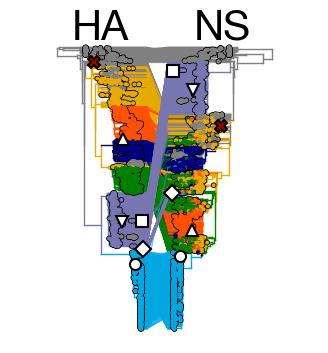

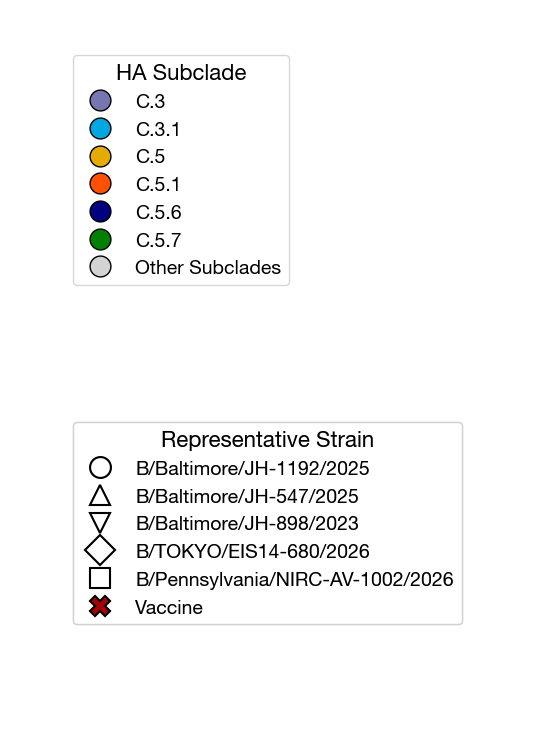

In [74]:
subclade_colors = {
            "C.3": "#7876B1",
            "C.3.1": "#00A7E1",
            "C.5": "#e6ab02",
            "C.5.1": "#FF5003",
            "C.5.6": "#010080",
            "C.5.7": "green"
        }

tip_shapes={
        "JH251192": 
            {"marker": "o", 
            "facecolor": "white", 
            "edgecolor": "black",
            "markersize": 8, 
            "display_name": "B/Baltimore/JH-1192/2025"},
        "JH24547": 
            {"marker": "^", 
            "facecolor": "white", 
            "edgecolor": "black", 
            "markersize": 8, 
            "display_name": "B/Baltimore/JH-547/2025" },
        "JH23898": 
            {"marker": "v", 
            "facecolor": "white", 
            "edgecolor": "black", 
            "markersize": 8, 
            "display_name": "B/Baltimore/JH-898/2023"},
        "B/TOKYO/EIS14680/2026": 
            {"marker": "D", 
            "facecolor": "white", 
            "edgecolor": "black", 
            "markersize": 8, 
            "display_name": "B/TOKYO/EIS14-680/2026"},
        "B/Pennsylvania/NIRCAV1002/2026": 
            {"marker": "s", 
            "facecolor": "white", 
            "edgecolor": "black", 
            "markersize": 8, 
            "display_name": "B/Pennsylvania/NIRC-AV-1002/2026"},
        "B/Austria/1359417/2021-E3(Am2/Al1)": 
            {"marker": "X", 
            "facecolor": "#A50104", 
            "edgecolor": "black", 
            "markersize": 8, 
            "display_name": "Vaccine"}
    }


genome_segment_compare = ["NA", 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS']

for segment in genome_segment_compare:
    plot_two_segment_tanglegram(
        tree1_name="HA",
        tree2_name=segment,
        trees=trees,
        subclade_colors=subclade_colors,
        tip_shapes=tip_shapes,
        figsize=(6, 5), 
        line_alpha=0.6,
        line_width=1,
        tree_line_width=1,
        point_size=8,
        title_fontsize=30,
        legend_fontsize=7,  
        legend_title_fontsize=9,  
        legend_marker_size=8,  
        legend_position_clades=(0.9, 0.25),  
        legend_position_shapes=(0.9, 0.1),  
        highlight_subclade='C.3',
        show_legend=False,
        #show_subclade_legend=True,
        #show_shapes_legend=True,
        right_margin=0.75, 
        save_path=f"../figures/phylogeny_tanglegram_HA_{segment}.png"
    )

# extract legend 

fig_legend, ax_legend = plt.subplots(figsize=(6, 8), facecolor='w')
ax_legend.axis('off')

# Subclade legend entries
legend_clades = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=1,
        markersize=15,
        linestyle='None',
        label=subclade
    )
    for subclade, color in subclade_colors.items()
]

legend_clades.append(
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='lightgrey',
        markeredgecolor='black',
        markeredgewidth=1,
        markersize=15,
        linestyle='None',
        label='Other Subclades'
    )
)

# Tip shapes legend entries
legend_shapes = [
    Line2D(
        [0], [0],
        marker=shape.get("marker", "o"),
        label=shape.get("display_name", tip),
        markerfacecolor=shape.get("facecolor", "white"),
        markeredgecolor=shape.get("edgecolor", "black"),
        markeredgewidth=1.5,
        markersize=15,
        linestyle='None',
        color='w'
    )
    for tip, shape in tip_shapes.items()
]

# Add subclade legend
legend1 = ax_legend.legend(
    handles=legend_clades,
    loc='upper left',
    bbox_to_anchor=(0.1, 0.95),
    fontsize=14,
    frameon=True,
    title="HA Subclade",
    title_fontsize=16
)
ax_legend.add_artist(legend1)

# Add shapes legend
legend2 = ax_legend.legend(
    handles=legend_shapes,
    loc='upper left',
    bbox_to_anchor=(0.1, 0.45),
    fontsize=14,
    frameon=True,
    title="Representative Strain",
    title_fontsize=16
)
ax_legend.add_artist(legend2)

plt.tight_layout()
plt.savefig("../figures/phylogeney_tanglegram_2segmentlegend.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



# Multi-Segment Tanglegrams

#### Define Universal Plotting Function

In [46]:
import baltic as bt
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_multi_segment_tanglegram(
    tree_names,
    trees,
    subclade_colors,
    traitName='subclade',
    tip_shapes=None,
    figsize=(17, 15),
    save_path=None,
    line_alpha=0.5,
    line_width=1,
    tree_line_width=4,
    point_size=10,
    displaceAmount=5,
    title_fontsize=60,
    legend_fontsize=25,
    legend_title_fontsize=28,
    legend_position_clades=(0.83, 0.67),
    legend_position_shapes=(0.83, 0.3),
    highlight_subclade=None,
    show_legend=True
):
    """
    Plot a multi-segment tanglegram comparing phylogenetic trees across segments.
    
    Parameters
    ----------
    tree_names : list
        List of segment names to include, in order (e.g., ['HA', 'NA', 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS'])
    trees : dict
        Dictionary mapping segment names to baltic tree objects
    subclade_colors : dict
        Dictionary mapping subclade names to colors (e.g., {"C.5.1": "#FF5003", "C.3": "#7876B1"})
    traitName : str, optional
        Name of the trait to color by (default: 'subclade')
    tip_shapes : dict, optional
        Dictionary mapping tip names to marker properties. Each entry can include:
        - marker: marker shape (default: 'o')
        - facecolor: fill color (default: 'white')
        - edgecolor: edge color (default: 'black')
        - markersize: size of marker (default: 20)
        - markeredgewidth: edge width (default: 1.5)
        - zorder: drawing order (default: 200)
        - display_name: name to show in legend (default: tip name)
    figsize : tuple, optional
        Figure size (default: (17, 15))
    save_path : str, optional
        Path to save the figure (default: None, doesn't save)
    line_alpha : float, optional
        Transparency of connecting lines (default: 0.5)
    line_width : float, optional
        Width of connecting lines (default: 1)
    tree_line_width : float, optional
        Width of tree branches (default: 4)
    point_size : float, optional
        Size of tip points (default: 10)
    displaceAmount : float, optional
        Gap between trees (default: 5)
    title_fontsize : float, optional
        Font size for segment titles (default: 60)
    legend_fontsize : float, optional
        Font size for legend entries (default: 25)
    legend_title_fontsize : float, optional
        Font size for legend titles (default: 28)
    legend_position_clades : tuple, optional
        Position of subclade legend (default: (0.83, 0.67))
    legend_position_shapes : tuple, optional
        Position of tip shapes legend (default: (0.83, 0.3))
    highlight_subclade : str, optional
        Subclade to draw on top with higher zorder (default: None)
    show_legend : bool, optional
        Whether to show legends (default: True)
    
    Returns
    -------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Set up figure
    fig, ax = plt.subplots(figsize=figsize, facecolor='w')
    
    cumulative_displace = 0
    
    # ---- Precompute tip positions for each tree ----
    tip_positions = {}
    for tr in tree_names:
        tree = trees[tr]
        positions = {}
        for k in tree.Objects:
            if k.branchType == 'leaf':
                positions[k.name] = (k.height, k.y)
        tip_positions[tr] = positions
    
    # Get max ySpan across all trees for consistent y-axis
    max_yspan = max(trees[tr].ySpan for tr in tree_names)
    
    # ---- Plot each tree ----
    for t, tr in enumerate(tree_names):
        cur_tree = trees[tr]
        
        # Need to capture cumulative_displace in closure properly
        current_displace = cumulative_displace
        x_attr = lambda k, d=current_displace: k.height + d
        
        # Tree segment label
        ax.text(
            cumulative_displace + cur_tree.treeHeight / 2,
            max_yspan + 1.5,
            tr,
            ha='center',
            va='bottom',
            fontsize=title_fontsize,
            fontweight='normal'
        )
        
        # Color function for nodes
        def colour_func(node):
            return subclade_colors.get(node.traits.get(traitName), 'grey')
        
        # Plot tree
        cur_tree.plotTree(ax, x_attr=x_attr, width=tree_line_width, colour="black")
        cur_tree.plotPoints(ax, x_attr=x_attr, size=point_size, colour=colour_func, zorder=100)
        
        # Plot special markers
        if tip_shapes:
            for k in cur_tree.Objects:
                if k.branchType == 'leaf' and k.name in tip_shapes:
                    shape = tip_shapes[k.name]
                    ax.plot(
                        x_attr(k), k.y,
                        marker=shape.get("marker", "o"),
                        markerfacecolor=shape.get("facecolor", "white"),
                        markeredgecolor=shape.get("edgecolor", "black"),
                        markeredgewidth=shape.get("markeredgewidth", 1.5),
                        markersize=shape.get("markersize", 20),
                        linestyle='None',
                        zorder=shape.get("zorder", 200)
                    )
        
        # Draw linking lines to next tree
        if t != len(tree_names) - 1:
            next_tree = tree_names[t + 1]
            next_tree_positions = tip_positions[next_tree]
            nextIncrement = cumulative_displace + cur_tree.treeHeight
            
            # Pass 1: draw non-highlighted subclades first
            for k in cur_tree.Objects:
                if k.branchType == 'leaf' and k.name in next_tree_positions:
                    subclade = k.traits.get(traitName)
                    if subclade != highlight_subclade:
                        y = k.y
                        next_x, next_y = next_tree_positions[k.name]
                        next_x += nextIncrement + displaceAmount
                        color = subclade_colors.get(subclade, 'lightgrey')
                        z = 1 if subclade in subclade_colors else 0
                        ax.plot(
                            [x_attr(k), nextIncrement + 0.05 * displaceAmount,
                             nextIncrement + 0.95 * displaceAmount, next_x],
                            [y, y, next_y, next_y],
                            lw=line_width, ls='-', color=color, alpha=line_alpha, zorder=z
                        )
            
            # Pass 2: draw highlighted subclade on top
            if highlight_subclade:
                for k in cur_tree.Objects:
                    if k.branchType == 'leaf' and k.name in next_tree_positions:
                        subclade = k.traits.get(traitName)
                        if subclade == highlight_subclade:
                            y = k.y
                            next_x, next_y = next_tree_positions[k.name]
                            next_x += nextIncrement + displaceAmount
                            color = subclade_colors.get(highlight_subclade, 'lightgrey')
                            ax.plot(
                                [x_attr(k), nextIncrement + 0.05 * displaceAmount,
                                 nextIncrement + 0.95 * displaceAmount, next_x],
                                [y, y, next_y, next_y],
                                lw=line_width, ls='-', color=color, alpha=line_alpha, zorder=2
                            )
        
        cumulative_displace += cur_tree.treeHeight + displaceAmount
    
    # ---- Final formatting ----
    for loc in ['top', 'right', 'left', 'bottom']:
        ax.spines[loc].set_visible(False)
    ax.tick_params(axis='x', size=0)
    ax.tick_params(axis='y', size=0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_ylim(-1, max_yspan + 2)
    ax.set_xlim(-5, cumulative_displace + 20)
    
    # ---- Build legends ----
    if show_legend:
        # Determine which subclades are actually present
        present_subclades = set()
        for tr in tree_names:
            for k in trees[tr].Objects:
                if k.branchType == 'leaf':
                    present_subclades.add(k.traits.get(traitName))
        
        # Subclade color legend
        legend_clades = [
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=color,
                markeredgecolor='black',
                markeredgewidth=1,
                markersize=15,
                linestyle='None',
                label=subclade
            )
            for subclade, color in subclade_colors.items()
            if subclade in present_subclades
        ]
        
        # Add "Other Subclades" if there are any not in subclade_colors
    
        if any(s not in subclade_colors for s in present_subclades if s is not None):
            legend_clades.append(
                Line2D(
                    [0], [0],
                    marker='o',
                    color='w',
                    markerfacecolor='lightgrey',
                    markeredgecolor='black',
                    markeredgewidth=1,
                    markersize=15,
                    linestyle='None',
                    label='Other Subclades'
                )
            )

        # Tip shape legend
        legend_shapes = []
        if tip_shapes:
            legend_shapes = [
                Line2D(
                    [0], [0],
                    marker=shape.get("marker", "o"),
                    label=shape.get("display_name", tip),
                    markerfacecolor=shape.get("facecolor", "white"),
                    markeredgecolor=shape.get("edgecolor", "black"),
                    markeredgewidth=1.5,
                    markersize=20, # shape.get("markersize", 20),
                    linestyle='None',
                    color='w'
                )
                for tip, shape in tip_shapes.items()
            ]
        
        # Add subclade legend
        legend1 = ax.legend(
            handles=legend_clades,
            loc='center left',
            bbox_to_anchor=legend_position_clades,
            fontsize=legend_fontsize,
            frameon=True,
            title="HA Subclade",
            title_fontsize=legend_title_fontsize
        )
        ax.add_artist(legend1)
        
        # Add tip shapes legend
        if legend_shapes:
            legend2 = ax.legend(
                handles=legend_shapes,
                loc='center left',
                bbox_to_anchor=legend_position_shapes,
                fontsize=legend_fontsize,
                frameon=True,
                title="Representative Strains",
                title_fontsize=legend_title_fontsize
            )
            ax.add_artist(legend2)
    
    plt.subplots_adjust(bottom=0.15)
    plt.tight_layout(rect=[0, 0, 1.5, 1])
    
    # Save figure if path provided
    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.2,
            transparent=False,
            facecolor='white'
        )
        print(f"Saved tanglegram to {save_path}")
    
    plt.show()
    
    return fig, ax

##### Multi-tree Tanglegram for C.3, C.3.1, C.5.1, and C.5.7 

Saved tanglegram to ../figures/phylogeny_tanglegram_C.3-C.3.1-C.5.7.png


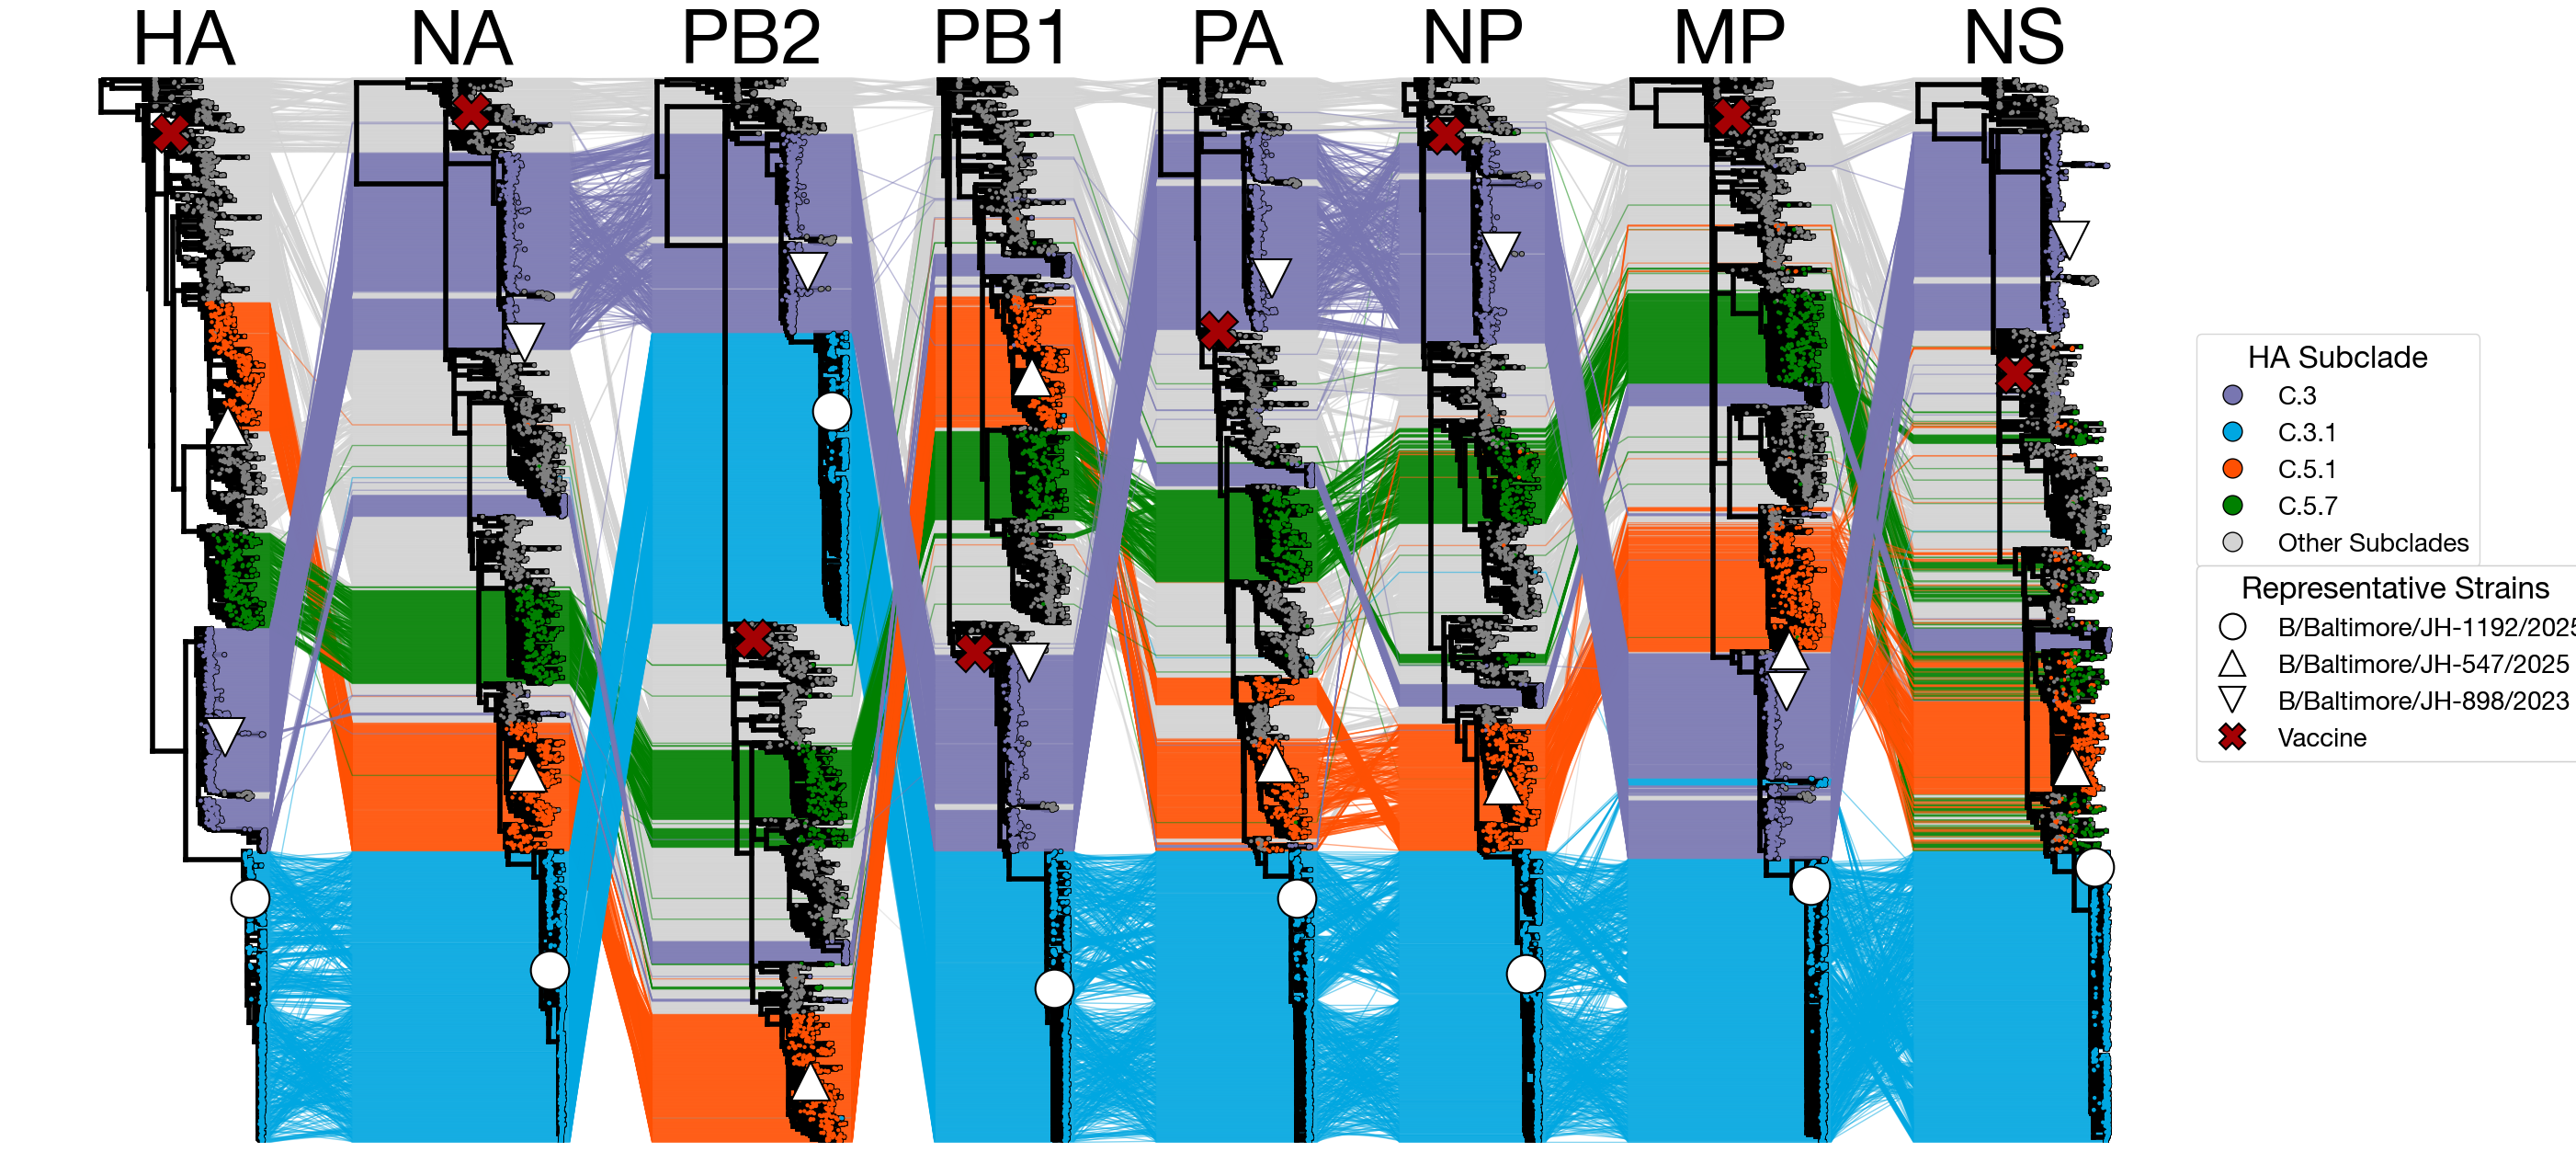

(<Figure size 1900x1300 with 1 Axes>, <Axes: >)

In [83]:
subclade_colors = {
    "C.3": "#7876B1",
    "C.3.1": "#00A7E1",
    "C.5.1": "#FF5003",
    "C.5.7": "green"
}

tip_shapes = {
    "JH251192": {
        "marker": "o",
        "facecolor": "white",
        "edgecolor": "black",
        "markersize": 30,
        "display_name": "B/Baltimore/JH-1192/2025"
    },
    "JH24547": {
        "marker": "^",
        "facecolor": "white",
        "edgecolor": "black",
        "markersize": 30,
        "display_name": "B/Baltimore/JH-547/2025"
    },
    "JH23898": {
        "marker": "v",
        "facecolor": "white",
        "edgecolor": "black",
        "markersize": 30,
        "display_name": "B/Baltimore/JH-898/2023"
    },
    "B/Austria/1359417/2021-E3(Am2/Al1)": {
        "marker": "X",
        "facecolor": "#A50104",
        "edgecolor": "black",
        "markersize": 30,
        "display_name": "Vaccine"
    }
}

tree_names = ['HA', 'NA', 'PB2', 'PB1', 'PA', 'NP', 'MP', 'NS']

plot_multi_segment_tanglegram(
    tree_names=tree_names,
    trees=trees,
    subclade_colors=subclade_colors,
    traitName='subclade',
    tip_shapes=tip_shapes,
    figsize=(19, 13), 
    save_path="../figures/phylogeny_tanglegram_C.3-C.3.1-C.5.7.png",
    line_alpha=0.5,
    line_width=1,
    tree_line_width=4,
    point_size=10,
    displaceAmount=5,
    title_fontsize=60,
    legend_fontsize=20,  
    legend_title_fontsize=24, 
    legend_position_clades=(0.85, 0.65), 
    legend_position_shapes=(0.85, 0.45),
    highlight_subclade='C.3',
    show_legend=True
)

##### Multi-tree Tanglegram for C.3, C.3.1, C.5.6, C.5 and C.5.7

# Calculating tMRCA between C.3 and C.3re by segment

## HA 

In [ ]:
myTree, mymeta = bt.loadJSON("../auspice/vic/ha.json")
tmrca_matrix = myTree.allTMRCAs()


Tree height: 10.624000
Tree length: 1693.342000

Numbers of objects in tree: 6466 (2915 nodes and 3551 leaves)



In [82]:
tip1, tip2 = "JH251192", "JH24547" #JH251289 = C.3 , JH251043=C.5.1
print(f"TMRCA between {tip1} and {tip2}: {tmrca_matrix[tip1][tip2]}")

tip3, tip4 = "JH251192", "JH23898" #JH251289 = C.3 , JH251043=C.5.1
print(f"TMRCA between {tip3} and {tip4}: {tmrca_matrix[tip3][tip4]}")

#TMRCA between JH251289 and JH251043: 2020.0531689328477
#TMRCA between JH251192 and JH24547: 2019.785 # second round

TMRCA between JH251192 and JH24547: 2019.785
TMRCA between JH251192 and JH23898: 2021.841


# Identify MRCA of C.3, C.3re and C.5.1 

In [60]:
#https://github.com/evogytis/baltic/wiki/Method-%60baltic.tree.commonAncestor%60

# Representatives for: 
# C.3 
# C.3re 
# C.5.1


# Assuming we have a tree and some leaf nodes
leaf1 = myTree.getExternal()[0]
leaf2 = myTree.getExternal()[5]
leaf3 = myTree.getExternal()[10]

# Find the common ancestor of these three leaves
mrca = myTree.commonAncestor([leaf1, leaf2, leaf3])

mrca
print(f"Common ancestor index: {mrca.index}")
print(f"Height of common ancestor: {mrca.height}")

# We can also use this to check if a set of leaves form a monophyletic group
all_leaves = myTree.getExternal()
group_of_interest = all_leaves[:5]  # First 5 leaves
mrca_of_group = myTree.commonAncestor(group_of_interest)

is_monophyletic = set(mrca_of_group.leaves) == set(leaf.name for leaf in group_of_interest)
print(f"Is the group monophyletic? {is_monophyletic}")



Common ancestor index: Root
Height of common ancestor: 0.0
Is the group monophyletic? False


# Genome Tree with an adjacent heatmap colored by the allele identity at site 197. 

In [61]:
import baltic as bt
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.collections import PatchCollection
import pandas as pd

# Optional styling
mpl.rcParams.update({
    'font.family': 'Helvetica Neue',
    'font.size': 18,
    'font.weight': 200,
    'axes.labelweight': 300
})

def plot_tree_with_heatmap(tree_file, positions, vaccine_strain=None, subclade_colors=None, figsize=None):
    if figsize is None:
        figsize = (6 + len(positions) * 0.6, 10)

    tree = bt.loadJSON(tree_file)[0]

    if subclade_colors is None:
        subclade_colors = {c: mpl.cm.tab10(i) for i, c in enumerate(
            ["C", "C.2", "C.3", "C.5", "C.5.1", "C.5.5", "C.5.6", "C.5.7"]
        )}

    tip_data = []
    for node in tree.Objects:
        if node.is_leaf():
            aa = {pos: None for pos in positions}
            ancestors = []
            tree.traverse_tree(
                cur_node=node,
                include_condition=lambda n: True,
                traverse_condition=lambda n: True,
                collect=ancestors,
                verbose=False
            )
            for anc in ancestors:
                for mut in anc.branchAttributes.get("mutations", {}).get("HA1", []):
                    p = int(mut[1:-1])
                    if p in positions:
                        aa[p] = mut[-1]
            tip_data.append({
                'name': node.name,
                'y': node.y,
                'subclade': node.traits.get('subclade'),
                **aa
            })

    df = pd.DataFrame(tip_data).set_index('name').sort_values('y')
    allele_set = sorted({a for pos in positions for a in df[pos].dropna().unique()})
    cmap = mpl.cm.get_cmap('tab10', len(allele_set))
    colmap = {a: cmap(i) for i, a in enumerate(allele_set)}
    colmap[None] = (0.9, 0.9, 0.9)

    fig, ax = plt.subplots(figsize=figsize)
    x_attr = lambda k: k.absoluteTime
    tree.plotTree(ax, connection_type="baltic", x_attr=x_attr, colour='k', width=1)
    tree.plotPoints(
        ax, x_attr=x_attr, size=10, outline=True, outline_colour="black",
        colour=lambda n: subclade_colors.get(n.traits.get('subclade'), 'lightgrey'),
        zorder=100
    )

    if vaccine_strain:
        for n in tree.Objects:
            if n.is_leaf() and n.name == vaccine_strain:
                ax.scatter(n.absoluteTime, n.y, s=150, marker='X',
                           facecolor=subclade_colors.get("C", 'red'),
                           edgecolor='black', linewidth=1.5, zorder=200)
                break

    years = list(range(int(min(o.absoluteTime for o in tree.Objects)),
                       int(max(o.absoluteTime for o in tree.Objects)) + 2))
    for i, y0 in enumerate(years[:-1]):
        if i % 2 == 0:
            ax.axvspan(y0, y0 + 1, color='grey', alpha=0.1)
    ax.set_xticks(years)
    ax.set_ylim(-1, max(o.y for o in tree.Objects) + 1)
    ax.tick_params(axis='y', left=False, labelleft=False)
    for spine in ['top', 'left', 'right']:
        ax.spines[spine].set_visible(False)

    left = ax.get_position().x1 + 0.005
    width = 0.02 * len(positions)
    heat_ax = fig.add_axes([left, ax.get_position().y0, width, ax.get_position().height])
    heat_ax.set_ylim(ax.get_ylim())
    heat_ax.set_xlim(0, len(positions))
    heat_ax.axis('off')

    patches, colors = [], []
    for _, row in df.iterrows():
        for i, pos in enumerate(positions):
            patches.append(Rectangle((i, row['y'] - 0.4), 1, 0.8))
            colors.append(colmap.get(row[pos]))
    heat_ax.add_collection(PatchCollection(patches, facecolor=colors, edgecolor='none'))

    for i, pos in enumerate(positions):
        heat_ax.text(i + 0.5, ax.get_ylim()[1] + 0.5, str(pos),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

    legend_handles = [Patch(color=colmap[a], label=a or 'NA') for a in allele_set]
    fig.legend(handles=legend_handles, title='AA allele', loc='upper right', frameon=False)
    plt.show()


In [62]:
plot_tree_with_heatmap(
    "../auspice/vic/ha.json",
    positions=[197, 203, 233, 255],
    vaccine_strain="B/Austria/1359417/2021-E3(Am2/Al1)"
)



Tree height: 10.624000
Tree length: 1693.342000

Numbers of objects in tree: 6466 (2915 nodes and 3551 leaves)



AttributeError: 'leaf' object has no attribute 'branchAttributes'

# Refined C.3 NS gene trees 

Less parsimodious approach to refine the C.3 NS gene tree by removing the C.3re clade and its descendants.

In [18]:
import baltic as bt
from glob import glob
from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests

from io import StringIO as sio
from io import BytesIO as csio

from Bio import Phylo


treefiles = glob('../auspice/plotting/*.json')

# import only the HA and the refined ns segment tree
segments=['HA', 'NS_tree']

trees={} ## dict
for segment in segments:
    print(segment, )
    tree_location = f"../auspice/vic/{segment}.json"

    ll = bt.loadJSON(tree_location)
    trees[segment]=ll[0] ## add ONLY the tree object to dict

print('\nDone!')

HA

Tree height: 8.022347
Tree length: 1741.294099
annotations present

Numbers of objects in tree: 6616 (2779 nodes and 3837 leaves)

NS_tree

Tree height: 4.666000
Tree length: 2088.105000
annotations present

Numbers of objects in tree: 6964 (3127 nodes and 3837 leaves)


Done!


In [21]:
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

def plot_two_segment_tanglegram(
    tree1_name,
    tree2_name,
    subclade_colors,
    trees,
    traitName='subclade',
    tip_shapes=None,
    figsize=(20, 10),
    save_path=None
):
    fig = plt.figure(figsize=figsize, facecolor='w')
    gs = GridSpec(1, 1, hspace=0.0, wspace=0.0)
    ax = plt.subplot(gs[0])

    tree1 = trees[tree1_name]
    tree2 = trees[tree2_name]

    def c_func(k):
        return subclade_colors.get(k.traits.get(traitName), 'grey')

    x_attr1 = lambda k: k.height
    tree1.plotTree(ax, x_attr=x_attr1, width=1, colour=c_func)
    tree1.plotPoints(ax, x_attr=x_attr1, size=7, colour=c_func, zorder=100)

    max_yspan = max(tree1.ySpan, tree2.ySpan)
    ax.text(
        tree1.treeHeight / 2,
        max_yspan + 2.5,
        tree1_name,
        ha='center',
        va='bottom',
        fontsize=40,
        fontweight='normal'
    )

    skip = tree1.treeHeight * 0.35
    x_attr2 = lambda k: tree1.treeHeight + skip + tree2.treeHeight - k.height
    tree2.plotTree(ax, x_attr=x_attr2, width=1, colour=c_func)
    tree2.plotPoints(ax, x_attr=x_attr2, size=7, colour=c_func, zorder=100)

    ax.text(
        tree1.treeHeight + skip + tree2.treeHeight / 2,
        max_yspan + 2.5,
        tree2_name,
        ha='center',
        va='bottom',
        fontsize=40,
        fontweight='normal'
    )

    # ---- Plot special markers ----
    if tip_shapes:
        for tree, x_attr in zip([tree1, tree2], [x_attr1, x_attr2]):
            for k in tree.Objects:
                if k.branchType == 'leaf' and k.name in tip_shapes:
                    shape = tip_shapes[k.name]
                    ax.plot(
                        x_attr(k), k.y,
                        marker=shape.get("marker", "o"),
                        markerfacecolor=shape.get("facecolor", "white"),
                        markeredgecolor=shape.get("edgecolor", "black"),
                        markeredgewidth=shape.get("markeredgewidth", 1.5),
                        markersize=shape.get("markersize", 20),
                        linestyle='None',
                        zorder=shape.get("zorder", 200)
                    )

    # ---- Tangle lines with zorder ----
    for zorder_level in [0, 1, 2]:
        for k in filter(lambda x: x.branchType == 'leaf', tree1.Objects):
            x = k.height
            y = k.y
            subclade = k.traits.get(traitName)
            color = subclade_colors.get(subclade, 'grey')
            if subclade == 'C.3':
                z = 2
            elif subclade in subclade_colors:
                z = 1
            else:
                z = 0
            if z != zorder_level:
                continue

            matching = tree2.getBranches(
                lambda x2: x2.branchType == 'leaf' and x2.name == k.name,
                warn=False
            )
            if not matching:
                continue
            matching_tip = matching[0] if isinstance(matching, list) else matching
            match_y = matching_tip.y
            xs = [x, tree1.treeHeight + 0.15 * skip,
                  tree1.treeHeight + skip - 0.15 * skip,
                  x_attr2(matching_tip)]
            ys = [y, y, match_y, match_y]

            ax.plot(xs, ys, color=color, alpha=0.7, zorder=z)

    # ---- Clean up plot ----
    for loc in ['top', 'right', 'left', 'bottom']:
        ax.spines[loc].set_visible(False)
    ax.tick_params(axis='x', size=0)
    ax.tick_params(axis='y', size=0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    y_buffer = max_yspan * 0.05
    ax.set_ylim(-y_buffer, max_yspan + y_buffer + 3)
    ax.set_xlim(-5, tree1.treeHeight + skip + tree2.treeHeight + 5)

    plt.tight_layout()

    # ---- Legends ----
    # Subclades actually present
    present_subclades = {
        k.traits.get(traitName)
        for tree in [tree1, tree2]
        for k in tree.Objects
        if k.branchType == 'leaf'
    }

    legend_clades = [
        Line2D([0], [0], color=color, lw=8, label=subclade)
        for subclade, color in subclade_colors.items()
        if subclade in present_subclades
    ]
    if any(s not in subclade_colors for s in present_subclades):
        legend_clades.append(
            Line2D([0], [0], color='lightgrey', lw=8, label='Other Subclades')
        )

    legend_shapes = []
    if tip_shapes:
        legend_shapes = [
            Line2D(
                [0], [0],
                marker=shape.get("marker", "o"),
                label=("vaccine" if tip == "B/Austria/1359417/2021-E3(Am2/Al1)" else tip),
                markerfacecolor=shape.get("facecolor", "white"),
                markeredgecolor=shape.get("edgecolor", "black"),
                markeredgewidth=1.5,
                markersize=shape.get("markersize", 20),
                linestyle='None',
                color='w'
            )
            for tip, shape in tip_shapes.items()
        ]

    legend1 = ax.legend(
        handles=legend_clades,
        loc='center left',
        bbox_to_anchor=(0.83, 0.6),
        fontsize=10,
        frameon=True,
        title="Subclades",
        title_fontsize=24
    )
    ax.add_artist(legend1)

    if legend_shapes:
        legend2 = ax.legend(
            handles=legend_shapes,
            loc='center left',
            bbox_to_anchor=(0.83, 0.3),
            fontsize=10,
            frameon=True,
            title="Labeled Tips",
            title_fontsize=24
        )
        ax.add_artist(legend2)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved tanglegram to {save_path}")
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()


Saved tanglegram to ../figures/tanglegram_HA_NS_refined.png


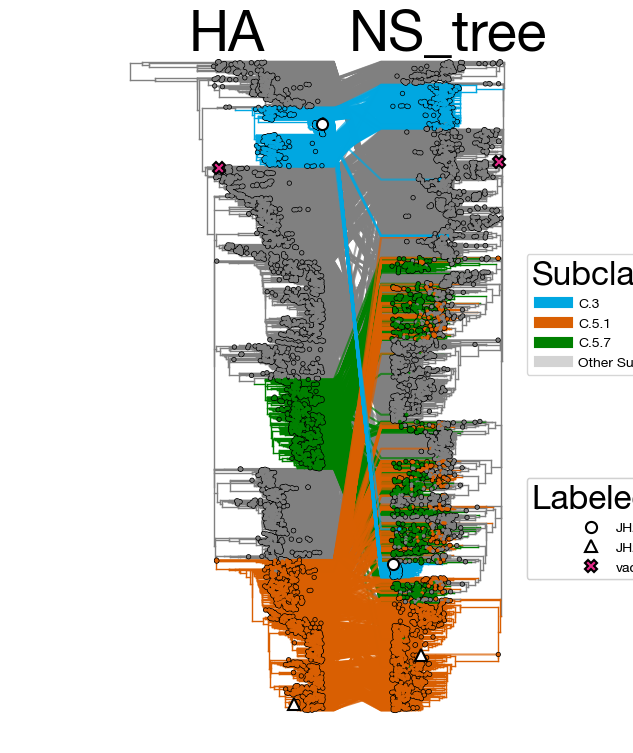

In [ ]:
plot_two_segment_tanglegram(
    "HA", "NS_tree",
    subclade_colors={
        "C.3": "#00A7E1",
        "C.5.1": "#d95f02",
        "C.5.7": "green",
    },
    trees=trees,
    figsize=(8, 8),
    tip_shapes={
        "JH251192": {"marker": "o", "facecolor": "white", "edgecolor": "black", "markersize": 8},
        "JH24547": {"marker": "^", "facecolor": "white", "edgecolor": "black", "markersize": 8},
        "B/Austria/1359417/2021-E3(Am2/Al1)": {
            "marker": "X", "facecolor": "#A50104", "edgecolor": "black", "markersize": 8
        }
    },
    save_path="../figures/tanglegram_HA_NS_refined.png"
)

In [3]:
# Color tip nodes by region identity
present_regions = sorted({
    k.traits.get("region")
    for tree in [trees["HA"], trees["NS"]]
    for k in tree.Objects
    if k.branchType == "leaf" and k.traits.get("region")
})

region_cmap = plt.get_cmap("tab20", max(len(present_regions), 1))
region_colors = {
    region: mpl.colors.to_hex(region_cmap(i))
    for i, region in enumerate(present_regions)
}

print("Regions in trees:", present_regions)

plot_two_segment_tanglegram(
    "HA", "NS_tree",
    subclade_colors=region_colors,
    traitName="region",
    trees=trees,
    figsize=(8, 8),
    tip_shapes={
        "JH251192": {"marker": "o", "facecolor": "white", "edgecolor": "black", "markersize": 8},
        "JH24547": {"marker": "^", "facecolor": "white", "edgecolor": "black", "markersize": 8},
        "B/Austria/1359417/2021-E3(Am2/Al1)": {
            "marker": "X", "facecolor": "#A50104", "edgecolor": "black", "markersize": 8
        }
    },
    save_path="../figures/tanglegram_HA_NS_refined_by_region.png"
)

NameError: name 'trees' is not defined